# Customer Segmentation & Retention Analytics
# End-to-End Jupyter Notebook
==========================================
# SECTION 1 — IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.cluster import KMeans
import datetime as dt


sns.set(style="whitegrid")

# SECTION 2 — LOAD TELCO CUSTOMER CHURN DATA

In [4]:
telco = pd.read_csv(r"D:\DATA_SCIENCE_PROJECTS\customer-segmentation-retention-analytics\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")


print("Telco Shape:", telco.shape)
telco.head()

Telco Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# SECTION 3 — TELCO DATA CLEANING

In [5]:
telco["TotalCharges"] = pd.to_numeric(telco["TotalCharges"], errors="coerce")


# Fill missing values
telco["TotalCharges"].fillna(telco["TotalCharges"].median(), inplace=True)


# Drop ID column
telco.drop("customerID", axis=1, inplace=True)


# Check missing values
telco.isnull().sum().head()

C:\Users\akkis\AppData\Local\Temp\ipykernel_16696\3264127345.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  telco["TotalCharges"].fillna(telco["TotalCharges"].median(), inplace=True)


gender           0
SeniorCitizen    0
Partner          0
Dependents       0
tenure           0
dtype: int64

# SECTION 4 — ENCODE CATEGORICAL FEATURES

In [7]:
le = LabelEncoder()


for col in telco.select_dtypes(include="object").columns:
    telco[col] = le.fit_transform(telco[col])

# SECTION 5 — TRAIN CHURN PREDICTION MODEL

In [8]:
X = telco.drop("Churn", axis=1)
y = telco["Churn"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


churn_model = RandomForestClassifier(n_estimators=200, random_state=42)
churn_model.fit(X_train, y_train)


y_pred = churn_model.predict(X_test)
y_prob = churn_model.predict_proba(X_test)[:, 1]


print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

ROC AUC: 0.825589656152316
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



# SECTION 6 — CHURN DRIVER ANALYSIS

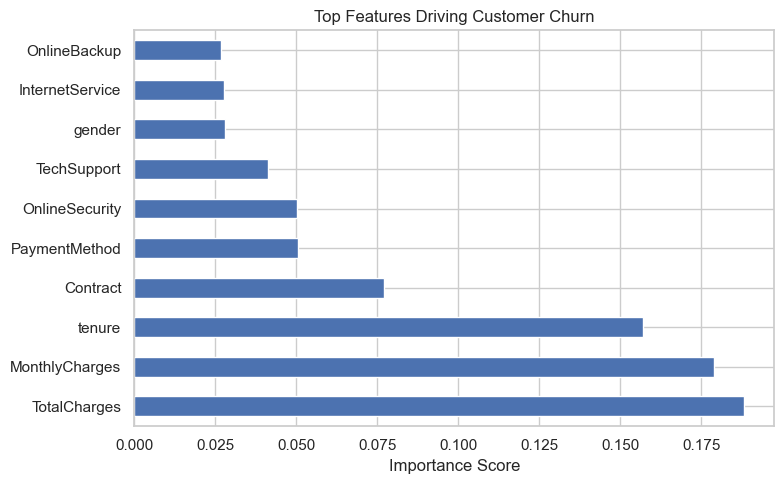

In [26]:
feature_importance = pd.Series(churn_model.feature_importances_, index=X.columns)
top_features = feature_importance.sort_values(ascending=False).head(10)


plt.figure(figsize=(8,5))
top_features.plot(kind="barh")
plt.title("Top Features Driving Customer Churn")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../results/churn_drivers.png")
plt.show()


# Save churn feature importance
feature_importance.sort_values(ascending=False)\
    .to_csv(r"D:\DATA_SCIENCE_PROJECTS\customer-segmentation-retention-analytics\data\processed/churn_feature_importance.csv")

# SECTION 7 — LOAD ONLINE RETAIL DATA

In [11]:
retail = pd.read_csv(r"D:\DATA_SCIENCE_PROJECTS\customer-segmentation-retention-analytics\data\raw\OnlineRetail.csv", encoding="ISO-8859-1")


print("Retail Shape:", retail.shape)
retail.head()

Retail Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# SECTION 8 — RETAIL DATA CLEANING

In [12]:
# Remove missing customers
retail = retail.dropna(subset=["CustomerID"])


# Remove cancelled / invalid orders
retail = retail[retail["Quantity"] > 0]
retail = retail[retail["UnitPrice"] > 0]


# Convert to datetime
retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"])


# Create revenue column
retail["Revenue"] = retail["Quantity"] * retail["UnitPrice"]


print("Cleaned Retail Shape:", retail.shape)

Cleaned Retail Shape: (397884, 9)


# SECTION 9 — BUILD RFM FEATURES

In [13]:
snapshot_date = retail["InvoiceDate"].max() + dt.timedelta(days=1)


rfm = retail.groupby("CustomerID").agg({
"InvoiceDate": lambda x: (snapshot_date - x.max()).days, # Recency
"InvoiceNo": "nunique", # Frequency
"Revenue": "sum" # Monetary
})


rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


# SECTION 10 — SCALE & CLUSTER CUSTOMERS

In [14]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)


kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# SECTION 11 — SEGMENT PROFILING

In [15]:
segment_summary = rfm.groupby("Cluster").mean()
segment_summary


segment_summary.to_csv(r"D:\DATA_SCIENCE_PROJECTS\customer-segmentation-retention-analytics\results\segment_profiles.csv")

# SECTION 12 — BUSINESS-FRIENDLY SEGMENT LABELS

In [16]:


def label_segment(row):
    if row["Recency"] < 50 and row["Monetary"] > 3000:
        return "High Value Loyal"
    elif row["Recency"] > 120 and row["Frequency"] < 5:
        return "At Risk"
    elif row["Frequency"] > 20:
        return "Frequent Buyers"
    else:
        return "Low Engagement"


rfm["Segment"] = rfm.apply(label_segment, axis=1)
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,At Risk
12347.0,2,7,4310.00,0,High Value Loyal
12348.0,75,4,1797.24,0,Low Engagement
12349.0,19,1,1757.55,0,Low Engagement
12350.0,310,1,334.40,1,At Risk


# SECTION 13 — IDENTIFY HIGH-VALUE AT-RISK CUSTOMERS

In [17]:
high_value_at_risk = rfm[
    (rfm["Segment"] == "At Risk") &
    (rfm["Monetary"] > rfm["Monetary"].median())
]


print("High Value At-Risk Customers:", high_value_at_risk.shape[0])
high_value_at_risk.head()

High Value At-Risk Customers: 223


,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,At Risk
12354.0,232,1,1079.40,1,At Risk
12377.0,315,2,1628.12,1,At Risk
12378.0,130,1,4008.62,0,At Risk
12405.0,149,1,1710.39,1,At Risk


# SECTION 14 — SAVE FINAL OUTPUTS

In [24]:
rfm.to_csv(r"D:\DATA_SCIENCE_PROJECTS\customer-segmentation-retention-analytics\data/processed/customer_segments.csv")
high_value_at_risk.to_csv(r"D:\DATA_SCIENCE_PROJECTS\customer-segmentation-retention-analytics\results/high_value_at_risk_customers.csv")

# SECTION 15 — FINAL NOTES

In [ ]:
print("Project Completed Successfully!")
print("Outputs saved in data/processed and results folders.")

Project Completed Successfully!
Outputs saved in data/processed and results folders.
